## TP3 KDE Kernel Density Estimation



In this TP 
1. You will implement the appropriate functions for probability density estimation using Gaussian kernels and you will study the effect of the h parameter using a simple artificial data set. 
2. You will implement the classification using Kernel density estimation. 

**For details see the description of the TP (TP3_KDE.pdf)**

In [16]:
from __future__ import division
import numpy as np
import random
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from matplotlib.pyplot import show
from itertools import combinations

# make figures appear inline
%matplotlib inline

# notebook will reload external python modules;
# see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Exersice 1
## Define training set
Let your training set consist of four points

In [17]:
# Define training set
c = np.array([[1,1],[1,4],[3,2.5],[4,2.5]])
n = c.shape[0]


## Define test set
Create a regular set of points which cover the plane $[0, 5] \times [0, 5]$  and stores them in testSet

In [18]:
# Define test set
min_X, max_X = 0, 5
min_Y, max_Y = 0, 5
intLength = 30
x = np.linspace(min_X, max_X, num=intLength)
y = np.linspace(min_Y, max_Y, num=intLength)
testSet = np.transpose([np.tile(x, len(y)), np.repeat(y, len(x))])
X,Y = np.meshgrid(x,y)

In [19]:
print('testSet shape: ', testSet.shape)

testSet shape:  (900, 2)


In [20]:
print(testSet)

[[0.         0.        ]
 [0.17241379 0.        ]
 [0.34482759 0.        ]
 ...
 [4.65517241 5.        ]
 [4.82758621 5.        ]
 [5.         5.        ]]


## Define the appropriate functions for probability density estimation using Gaussian kernels 

Implement the necessary functions in order to do Kernel density estimation using Gaussian kernel
 

In [21]:
# Gaussian Kernel


def GK(K, h: float, x: np.ndarray) -> np.ndarray:
    n = x.shape[0]
    d = x.shape[1]
    result = np.zeros(n)
    for i in np.arange(n):
        tmp = np.ones(n)
        for j in np.arange(i, d):
            tmp *= K((x[:, j] - x[i, j])/h)
        result += tmp
    return result / (n * h**d)
            
            
    

# Define parameters
def K(x: np.ndarray) -> np.ndarray:
    return 1 / np.sqrt(2 * np.pi) * np.exp(-1 / 2 * x**2)
# smoothing parameters
h = np.array([0.3,0.4,0.5])

# dimensionality of the test set
d = testSet.shape[1] 
print("dimensionality of the test set:"+str(d))

dimensionality of the test set:2


## Plot p(x|ci) for every ci using h : 0.3, 0.4, 0.5 and comment your results. For a specific center (training point) observe how h influences the result.



**Surface plots:**
https://matplotlib.org/2.0.2/mpl_toolkits/mplot3d/tutorial.html#surface-plots

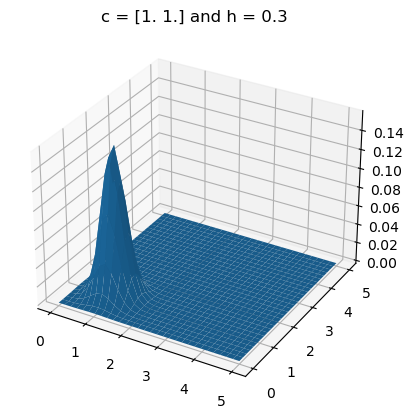

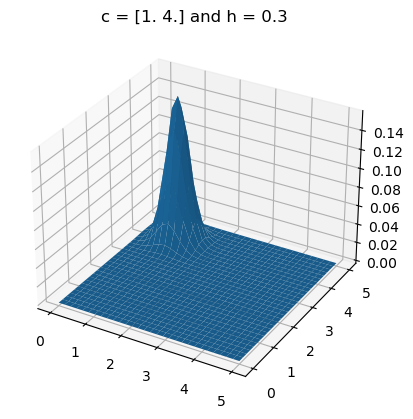

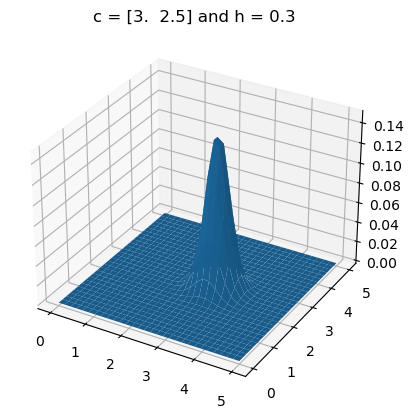

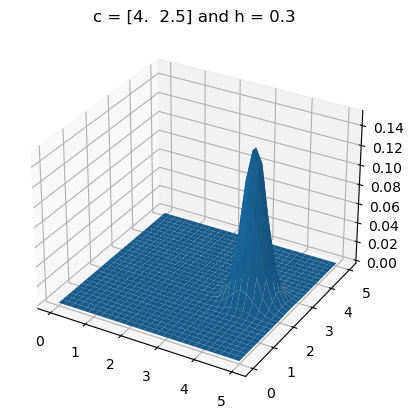

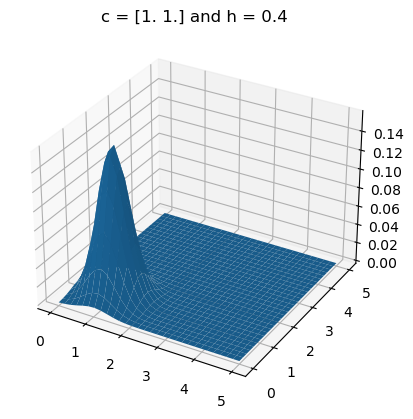

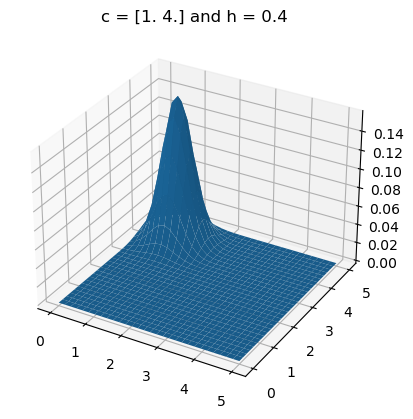

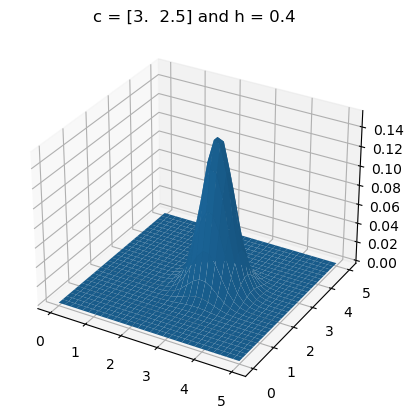

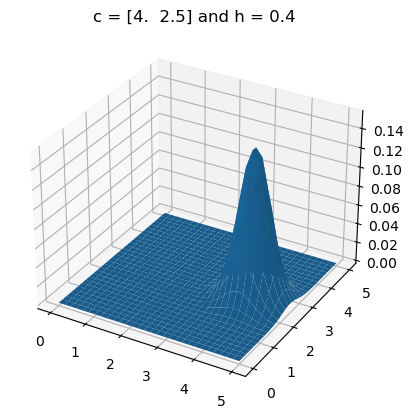

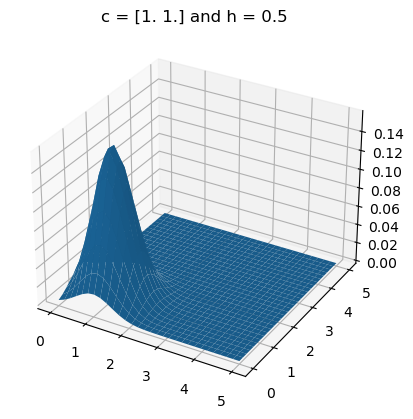

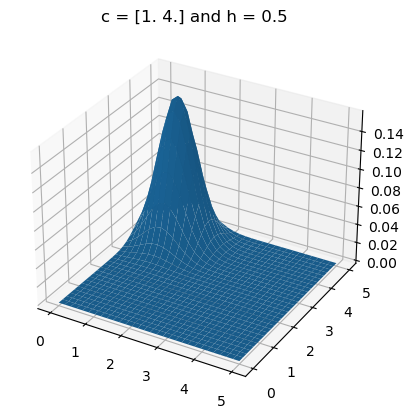

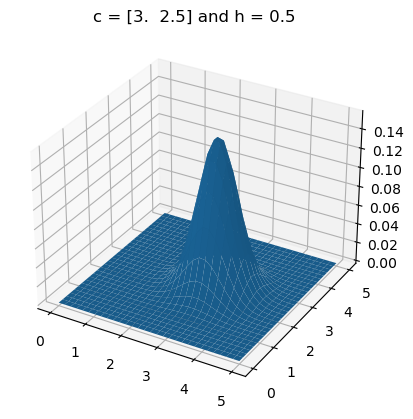

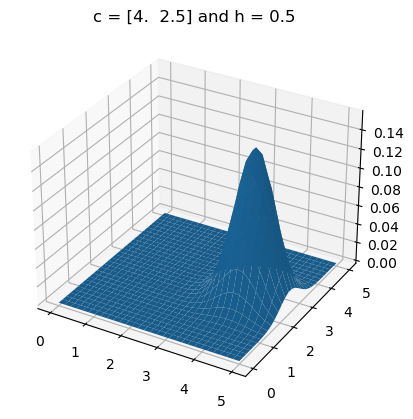

In [30]:
#plot conditional density function
def plot_p(K, X: np.ndarray, Y: np.ndarray, c: np.ndarray, h: float):
    for i in c:
        Z = K((X - i[0]) / h) * K((Y - i[1]) / h)

        fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
        ax.plot_surface(X, Y, Z)
        plt.title(f"c = {i} and h = {h}")

        plt.show()

for k in h:
    plot_p(K, X, Y, c, k)

## Plot p(x)  using h : 0.3, 0.4, 0.5. Observe the effect of h.

**Surface plots:**
https://matplotlib.org/2.0.2/mpl_toolkits/mplot3d/tutorial.html#surface-plots

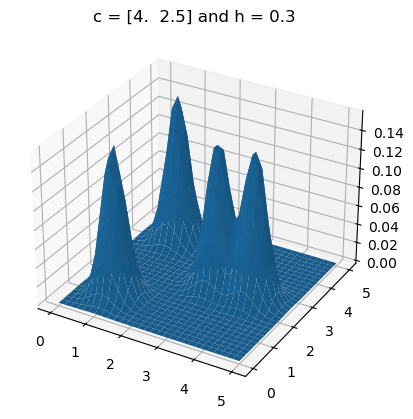

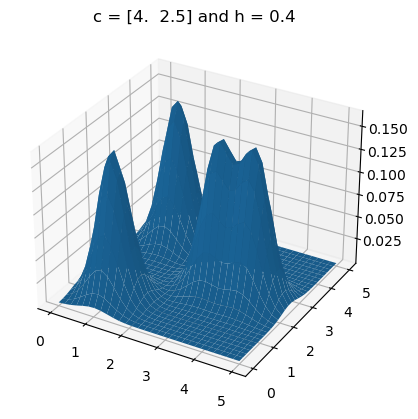

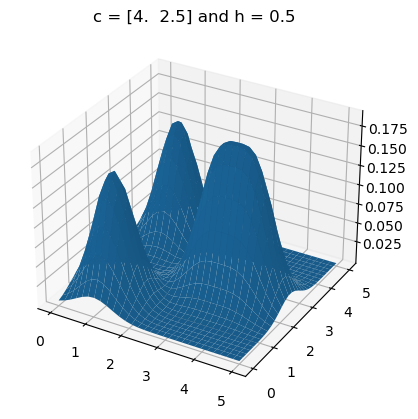

In [33]:
#plot density function 
#plot conditional density function
def plot_px(K, X: np.ndarray, Y: np.ndarray, c: np.ndarray, h: float):
    Z = np.zeros(X.shape)
    for i in c:
        Z += K((X - i[0]) / h) * K((Y - i[1]) / h)

    fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
    ax.plot_surface(X, Y, Z)
    plt.title(f"c = {i} and h = {h}")

    plt.show()

for k in h:
    plot_px(K, X, Y, c, k)

# Exersice 2
## Classification using Kernel density estimation

Implement the algorithm for classification using kernels.  To do that, you have to use the NaiveBayes() class  from the first TP (TP1\_NB).  New functions need to be added for the density estimation of the likelihoods  and you have to do all the necessary modifications to the existing functions of the NaiveBayes() class.

**For continuous attributes, use the Gaussian kernel, and for discrete attributes, use the corresponding kernel for discrete variables, depending on whether they are binary or not.**


In [62]:
import csv

# Loading the adult data set and transform it into an array.
with open('adult.csv', newline='') as csvfile: data = list(csv.reader(csvfile))
 
print('Name of each column:\n', np.array(data)[0, :], '\n')

header = np.array(data)[0, :]

# Delete the header containing the name of each feature
data = np.array(data)[1:, :]
np.random.seed(1234)
# shuffle the data
np.random.shuffle(data)

# print 5 first lines of dataset
print('5 first lines of dataset:\n', data[0:5, :], '\n')

data.shape


Name of each column:
 ['age' 'workclass' 'fnlwgt' 'education' 'educational-num' 'marital-status'
 'occupation' 'relationship' 'race' 'gender' 'capital-gain' 'capital-loss'
 'hours-per-week' 'native-country' 'income'] 

5 first lines of dataset:
 [['21' 'Private' '119156' 'HS-grad' '9' 'Never-married' 'Craft-repair'
  'Own-child' 'White' 'Male' '0' '0' '40' 'United-States' '<=50K']
 ['41' 'Private' '439919' '5th-6th' '3' 'Married-civ-spouse'
  'Farming-fishing' 'Husband' 'White' 'Male' '3411' '0' '40' 'Mexico'
  '<=50K']
 ['29' 'Private' '214689' 'Bachelors' '13' 'Never-married'
  'Exec-managerial' 'Not-in-family' 'White' 'Male' '0' '0' '40'
  'United-States' '<=50K']
 ['30' 'Self-emp-not-inc' '113838' 'Assoc-voc' '11' 'Married-civ-spouse'
  'Sales' 'Husband' 'White' 'Male' '3137' '0' '60' 'Germany' '<=50K']
 ['41' 'Private' '154076' 'Some-college' '10' 'Married-civ-spouse'
  'Adm-clerical' 'Husband' 'White' 'Male' '0' '0' '50' 'United-States'
  '>50K']] 



(48842, 15)

### As in the first TP\_NB, check for missing values, handle them if present, and split the dataset into training and testing sets (80/20) using a random seed.

In [121]:
def split_dataset(data: np.ndarray) -> np.ndarray:
    """
    Return split data 80%, 20% for training and test
    """
    delimiter = np.round(data.shape[0] * 0.8)
    index = np.arange(data.shape[0]).astype(int)
    mask_8 = index < delimiter
    mask_2 = index >= delimiter
    newdata = data.copy()
    np.random.shuffle(newdata)
    return newdata[mask_8, :], newdata[mask_2, :]

def gaussian_distribution(x: float, mean: float, var: float) -> float:
    return 1 / np.sqrt(2 * np.pi * var ** 2) * np.exp( -1 / 2 * ((x - mean)/var) ** 2)

def naive_bayes_training(data: np.ndarray, header: np.ndarray, label: int) -> dict:
    """
    header: np.ndarray
        the header of the data
    label: int
        the indice of the column which serve of labels
    """
    m = data.shape[0]
    n = data.shape[1]

    labels = np.unique(data[:, label], return_counts=True)

    training = {}

    for i in labels[0]:

        newdata = data[data[:, label] == i]

        tmp = {}

        for j in range(n):
            if j == label:
                pass
            else:
                tmp_2 = {}
                try:
                    values = newdata[:, j].astype(float)
                    tmp_2["mean"] = np.mean(values)
                    tmp_2["var"] = np.var(values)
                    
                except:
                    values, count = np.unique(newdata[:, j], return_counts=True)
                    total = count.sum()
                    for k in range(len(values)):
                        tmp_2[values[k]] = count[k] / total
                finally:
                    tmp[header[j]] = tmp_2
        training[i] = tmp
    return training

def evaluate_single(training: dict, value: dict):
    
    keys_value = value.keys()
    keys_training = training.keys()
    maximum = 0.
    evaluation = list(keys_training)[0]

    for i in keys_training:
        result = 1.
        for j in keys_value:
            if j not in training[i]:
                print(f"No key correspond to '{j}' ({i})! Please verify your headers !")
            else:
                header = training[i][j]
                if 'mean' in header.keys() and 'var' in header.keys():
                    result *= gaussian_distribution(float(value[j]), header['mean'], header['var'])
                else:
                    try:
                        result *= header[value[j]]
                    except:
                        result *= header['?']
        if result > maximum:
            evaluation = i
            maximum = result

    return evaluation

def array2dict(value: np.ndarray, header: np.ndarray) -> dict:
    result = {}
    for i in range(len(value)):
        result[header[i]] = value[i]
    return result


def evaluate(training: dict, values: np.ndarray, header: np.ndarray) -> np.ndarray:
    result = []
    for i in values[:, :-1]:
        result.append(evaluate_single(training, array2dict(i, header)))
    return np.asarray(result)


training = naive_bayes_training(data, header, 14)

#evaluate_single(training, {'age': '21', 'workclass': 'Private', 'fnlwgt': '119156', 'education': 'HS-grad', 'educational-num': '9', 'marital-status': 'Never-married', 'occupation': 'Craft-repair', 'relationship': 'Own-child', 'race': 'White', 'gender': 'Male', 'capital-gain': '0', 'capital-loss': '0', 'hours-per-week': '40', 'native-country': 'United-States'})

result = evaluate(training, data, header)

print(result)

error_rate = 0
for i in range(len(result)):
    if result[i] != data[i, -1]:
        error_rate += 1

for i in result:
    print(i)

print(error_rate)
            
        

['<=50K' '<=50K' '<=50K' ... '<=50K' '<=50K' '<=50K']
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
>50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K
<=50K

### Once your implementation is ready 
-  Apply the classifier with kernels to the **Adult dataset**. 
- Compute the test classification accuracy for **$h$: 0.3, 0.4, 0.5, 1.0**. 
- Discuss the effect of the $h$ parameter on the classification accuracy of the algorithm in detail.
